# 02 — Bearing vs. Direction

`compute_bearing` returns a number. That number is the **initial bearing** — the compass direction you face at the moment of departure.

For short distances, the bearing stays roughly constant along the path. For long distances, it does not. The Earth curves underneath you, and what started as a northeast heading gradually shifts as you travel.

This notebook separates two things students often conflate: *bearing* (a number computed at a single point) and *direction* (what the path actually does over its length).

In [1]:
import math
import json
from pathlib import Path

def compute_bearing(p1, p2):
    """Bearing from p1 to p2. Inputs: [lon, lat]. Output: degrees [0, 360)."""
    lon1, lat1 = math.radians(p1[0]), math.radians(p1[1])
    lon2, lat2 = math.radians(p2[0]), math.radians(p2[1])
    d_lon = lon2 - lon1
    x = math.sin(d_lon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(d_lon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def haversine_km(p1, p2):
    """Great-circle distance in km. Inputs: [lon, lat]."""
    R = 6371.0
    lon1, lat1 = math.radians(p1[0]), math.radians(p1[1])
    lon2, lat2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

with open(Path("data/bearing_examples.json")) as f:
    examples = json.load(f)

print("Ready.")

Ready.


## 1. Bearing Is an Initial Direction, Not a Constant

When you call `compute_bearing(p1, p2)`, you get one number. That number describes the direction to face **at p1** to head toward p2. It says nothing about what happens to your heading as you travel.

On a flat surface, the direction stays constant — walk northeast and you keep walking northeast forever. On a sphere, that is not true.

As you travel along a great circle (the shortest path between two points on a sphere), the lines of longitude you cross are converging. You are not moving in a straight line through space — you are arcing along a curved surface. Your compass heading **changes continuously** even if you never turn.

For short distances (under ~200 km), this effect is small enough to ignore. For long routes — city to city, continental distances, missile trajectories — the drift is significant and must be accounted for.

## 2. Measuring Bearing Drift Along a Path

The clearest way to see bearing drift is to walk a path in small steps and compute the bearing at each step. If the heading were constant, every bearing would be identical. On a sphere, they shift.

The function below interpolates `n` equally-spaced intermediate points between p1 and p2 along a straight line in coordinate space (not a true great circle, but close enough for visualization), then computes the bearing from each point to the next.

In [2]:
def bearing_along_path(p1, p2, n=10):
    """
    Interpolate n+1 points along the line from p1 to p2,
    then compute the bearing from each point to the next.
    Returns a list of (fraction_traveled, bearing) tuples.
    """
    results = []
    for i in range(n):
        t0 = i / n
        t1 = (i + 1) / n
        a = [p1[0] + t0 * (p2[0] - p1[0]), p1[1] + t0 * (p2[1] - p1[1])]
        b = [p1[0] + t1 * (p2[0] - p1[0]), p1[1] + t1 * (p2[1] - p1[1])]
        results.append((t0, compute_bearing(a, b)))
    return results


# Short route (~220 km): Wichita Falls → Oklahoma City
wf  = [-98.49, 33.91]
okc = [-97.52, 35.47]

# Long route (~7900 km): Dallas → London
dal = [-96.80, 32.78]
lon = [ -0.13, 51.51]

print("Wichita Falls → Oklahoma City (~220 km)")
print(f"  Initial bearing: {compute_bearing(wf, okc):.2f}°")
print(f"  {'Step':>6}  {'Bearing':>10}  {'Δ from initial':>16}")
wf_path = bearing_along_path(wf, okc, n=8)
initial = wf_path[0][1]
for frac, brg in wf_path:
    print(f"  {frac:>5.0%}   {brg:>9.2f}°  {brg - initial:>+15.2f}°")

print()
print("Dallas → London (~7900 km)")
print(f"  Initial bearing: {compute_bearing(dal, lon):.2f}°")
print(f"  {'Step':>6}  {'Bearing':>10}  {'Δ from initial':>16}")
dal_path = bearing_along_path(dal, lon, n=8)
initial2 = dal_path[0][1]
for frac, brg in dal_path:
    print(f"  {frac:>5.0%}   {brg:>9.2f}°  {brg - initial2:>+15.2f}°")

Wichita Falls → Oklahoma City (~220 km)
  Initial bearing: 26.80°
    Step     Bearing    Δ from initial
     0%       27.23°            +0.00°
    12%       27.18°            -0.05°
    25%       27.13°            -0.11°
    38%       27.07°            -0.16°
    50%       27.02°            -0.22°
    62%       26.96°            -0.27°
    75%       26.91°            -0.33°
    88%       26.85°            -0.38°

Dallas → London (~7900 km)
  Initial bearing: 41.56°
    Step     Bearing    Δ from initial
     0%       73.52°            +0.00°
    12%       72.95°            -0.57°
    25%       72.34°            -1.18°
    38%       71.69°            -1.83°
    50%       70.99°            -2.53°
    62%       70.23°            -3.28°
    75%       69.41°            -4.11°
    88%       68.51°            -5.00°


The short route drifts only a fraction of a degree — negligible. The long route to London drifts noticeably. By the time you are halfway across the Atlantic, the compass heading has shifted by several degrees from what it was at departure.

This is not a formula error. It is a geometric property of the sphere.

## 3. Longitude Convergence — Why the Heading Shifts

The root cause is that **lines of longitude are not parallel**. They fan out from the equator and converge at both poles. 

Imagine two longitude lines: `-97°` and `-96°`. At the equator they are about 111 km apart. At 35°N (Texas) they are about 91 km apart. At 60°N (southern Canada) they are about 56 km apart.

As you travel north along any path that is not exactly due north, you are also moving between longitude lines that are getting closer together. Your angular relationship to "due north" changes at every step — even if your physical trajectory is a smooth arc. That change in angular relationship *is* the bearing drift.

In [3]:
# Longitude spacing at different latitudes — demonstrates convergence
KM_PER_DEG_LAT = 111.32

print(f"{'Latitude':>10}  {'km per 1° lon':>15}  {'% of equator':>14}")
print("-" * 45)
for lat in range(0, 81, 10):
    km = KM_PER_DEG_LAT * math.cos(math.radians(lat))
    pct = km / KM_PER_DEG_LAT * 100
    print(f"{lat:>9}°  {km:>14.1f} km  {pct:>13.1f}%")

  Latitude    km per 1° lon    % of equator
---------------------------------------------
        0°           111.3 km          100.0%
       10°           109.6 km           98.5%
       20°           104.6 km           94.0%
       30°            96.4 km           86.6%
       40°            85.3 km           76.6%
       50°            71.6 km           64.3%
       60°            55.7 km           50.0%
       70°            38.1 km           34.2%
       80°            19.3 km           17.4%


## 4. Visualizing the Drift

A map makes the drift concrete. The plot below shows the Dallas → London path sampled at 12 intermediate points. At each point, a short arrow indicates the local bearing at that moment. Watch how the arrows rotate from northeast at departure toward a more northerly heading as the path arcs across the Atlantic.

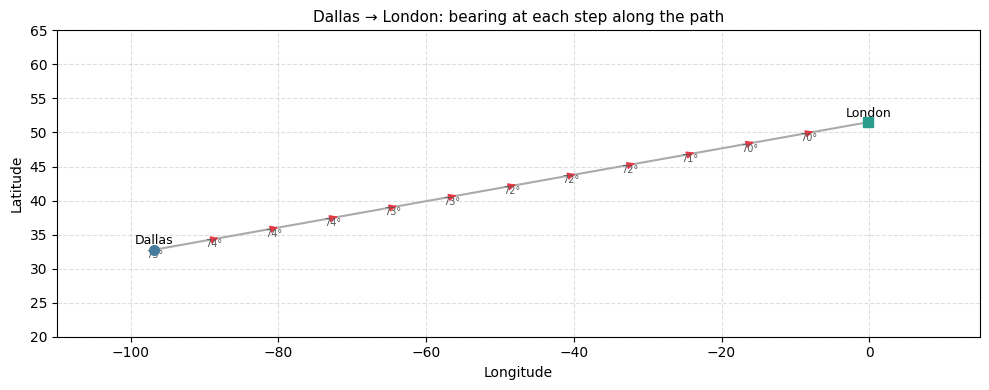

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

N = 12
path_points = [
    [dal[0] + i/N * (lon[0] - dal[0]), dal[1] + i/N * (lon[1] - dal[1])]
    for i in range(N + 1)
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_title("Dallas → London: bearing at each step along the path", fontsize=11)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Path line
lons_path = [p[0] for p in path_points]
lats_path = [p[1] for p in path_points]
ax.plot(lons_path, lats_path, "-", color="#aaaaaa", linewidth=1.5, zorder=1)

# Arrow at each intermediate point showing local bearing
arrow_len = 2.5  # degrees
for i in range(N):
    p  = path_points[i]
    p2 = path_points[i + 1]
    brg = compute_bearing(p, p2)
    # Convert bearing → matplotlib angle (degrees from East, CCW)
    mpl_angle = 90 - brg
    dx = arrow_len * math.cos(math.radians(mpl_angle))
    dy = arrow_len * math.sin(math.radians(mpl_angle))
    ax.annotate(
        "", xy=(p[0] + dx * 0.4, p[1] + dy * 0.4), xytext=(p[0], p[1]),
        arrowprops=dict(arrowstyle="-|>", color="#e63946", lw=1.2),
        zorder=3,
    )
    ax.text(p[0], p[1] - 1.2, f"{brg:.0f}°", ha="center", fontsize=7, color="#555555")

# Mark endpoints
ax.plot(*dal, "o", color="#457b9d", markersize=7, zorder=4)
ax.plot(*lon, "s", color="#2a9d8f", markersize=7, zorder=4)
ax.text(dal[0], dal[1] + 0.8, "Dallas", ha="center", fontsize=9)
ax.text(lon[0], lon[1] + 0.8, "London", ha="center", fontsize=9)

ax.set_xlim(-110, 15)
ax.set_ylim(20, 65)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Flat vs. Spherical: What "Straight" Means

On a flat map, a straight line between two points is the shortest path — and it has a constant bearing the whole way. On a sphere, the shortest path (a great circle) looks curved when drawn on a flat map, and its bearing changes continuously.

The two models agree well at short distances. At intercontinental distances, they diverge enough to matter.

| Model | Path shape | Bearing | Valid at |
|-------|-----------|---------|----------|
| Flat (Euclidean) | Straight line | Constant | < ~200 km |
| Spherical (great circle) | Curved arc on map | Varies along path | Any distance |

The practical consequence: if you compute a bearing and then apply it as a fixed heading for a long journey, you will not arrive at your destination. You will curve off course because the Earth has curved under you.

In [5]:
# Compare initial bearing vs bearing at the midpoint for routes of increasing length
base = [-98.49, 33.91]  # Wichita Falls

destinations = [
    ("Altus AFB (~90 km)",       [-99.27, 34.66]),
    ("Oklahoma City (~220 km)",  [-97.52, 35.47]),
    ("Kansas City (~560 km)",    [-94.58, 39.10]),
    ("Chicago (~1400 km)",       [-87.63, 41.88]),
    ("New York (~2400 km)",      [-74.01, 40.71]),
    ("London (~8800 km)",        [ -0.13, 51.51]),
]

print(f"{'Route':<30} {'Initial brg':>12}  {'Mid-path brg':>14}  {'Drift':>8}")
print("-" * 72)
for label, dest in destinations:
    mid = [(base[0] + dest[0]) / 2, (base[1] + dest[1]) / 2]
    initial = compute_bearing(base, dest)
    mid_brg = compute_bearing(mid, dest)
    drift   = mid_brg - initial
    print(f"{label:<30} {initial:>11.1f}°  {mid_brg:>13.1f}°  {drift:>+7.1f}°")

Route                           Initial brg    Mid-path brg     Drift
------------------------------------------------------------------------
Altus AFB (~90 km)                   319.5°          319.5°     -0.0°
Oklahoma City (~220 km)               26.8°           26.8°     +0.0°
Kansas City (~560 km)                 30.1°           30.2°     +0.1°
Chicago (~1400 km)                    43.8°           44.6°     +0.7°
New York (~2400 km)                   63.5°           66.5°     +3.0°
London (~8800 km)                     41.3°           57.6°    +16.2°


The drift is negligible for nearby targets and grows with distance. At intercontinental ranges the heading has rotated by several degrees before you are even halfway there.

---

## Exercise A — Drift by Direction

Bearing drift is not equal in all directions. A due-east path at mid-latitudes drifts differently than a northeast path.

Using Wichita Falls as the base point, compute initial vs. midpoint bearing for each of the four routes below. Which direction shows the most drift? Which shows the least?

```python
routes = [
    ("Due East (~900 km)",       [-87.0,  33.91]),
    ("Due North (~900 km)",      [-98.49, 41.99]),
    ("Northeast (~900 km)",      [-91.0,  40.0 ]),
    ("Southeast (~900 km)",      [-91.0,  27.0 ]),
]
```

In [1]:
import math

def compute_bearing(p1, p2):
    """
    Compute initial bearing from p1 to p2.
    Points are [lon, lat] in degrees.
    Returns bearing in degrees [0, 360).
    """

    lon1, lat1 = map(math.radians, p1)
    lon2, lat2 = map(math.radians, p2)

    dlon = lon2 - lon1

    x = math.sin(dlon) * math.cos(lat2)

    y = (
        math.cos(lat1) * math.sin(lat2)
        - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    )

    theta = math.atan2(x, y)

    bearing = (math.degrees(theta) + 360) % 360

    return bearing

In [2]:
import math

def great_circle_midpoint(p1, p2):
    """
    Compute midpoint along a great-circle path.
    Points are [lon, lat] in degrees.
    Returns [lon, lat] in degrees.
    """

    lon1, lat1 = map(math.radians, p1)
    lon2, lat2 = map(math.radians, p2)

    bx = math.cos(lat2) * math.cos(lon2 - lon1)
    by = math.cos(lat2) * math.sin(lon2 - lon1)

    lat3 = math.atan2(
        math.sin(lat1) + math.sin(lat2),
        math.sqrt((math.cos(lat1) + bx)**2 + by**2)
    )

    lon3 = lon1 + math.atan2(
        by,
        math.cos(lat1) + bx
    )

    return [
        math.degrees(lon3),
        math.degrees(lat3)
    ]

In [3]:
base = [-98.49, 33.91]

routes = [
    ("Due East (~900 km)",   [-87.0,  33.91]),
    ("Due North (~900 km)",  [-98.49, 41.99]),
    ("Northeast (~900 km)",  [-91.0,  40.0 ]),
    ("Southeast (~900 km)",  [-91.0,  27.0 ]),
]

results = []

for label, dest in routes:
    midpoint = great_circle_midpoint(base, dest)

    initial_bearing = compute_bearing(base, dest)
    midpoint_bearing = compute_bearing(midpoint, dest)

    drift = abs(midpoint_bearing - initial_bearing)

    # handle wraparound near 0/360
    if drift > 180:
        drift = 360 - drift

    results.append((drift, label, initial_bearing, midpoint_bearing))

print(f"{'Route':<25} {'Initial':>10} {'Midpoint':>10} {'Drift':>10}")
print("-" * 60)

for drift, label, initial, mid in results:
    print(f"{label:<25} {initial:>9.2f}° {mid:>9.2f}° {drift:>9.2f}°")

most = max(results, key=lambda x: x[0])
least = min(results, key=lambda x: x[0])

print("\nMost drift:")
print(f"{most[1]} with {most[0]:.2f}°")

print("\nLeast drift:")
print(f"{least[1]} with {least[0]:.2f}°")

Route                        Initial   Midpoint      Drift
------------------------------------------------------------
Due East (~900 km)            86.79°     90.00°      3.21°
Due North (~900 km)            0.00°      0.00°      0.00°
Northeast (~900 km)           42.30°     44.39°      2.09°
Southeast (~900 km)          134.98°    137.05°      2.07°

Most drift:
Due East (~900 km) with 3.21°

Least drift:
Due North (~900 km) with 0.00°


## Exercise B — When Does Drift Become Significant?

Using the `bearing_along_path` function from Section 2, find the approximate distance at which bearing drift first exceeds **2°** for a northeast path from Wichita Falls.

Step east and north by varying the destination longitude/latitude and report the total distance (using `haversine_km`) alongside the max drift across the path.

In [1]:
import math

# -------------------------------------------------
# Haversine distance
# -------------------------------------------------

def haversine_km(p1, p2):

    lon1, lat1 = map(math.radians, p1)
    lon2, lat2 = map(math.radians, p2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        math.sin(dlat / 2)**2
        + math.cos(lat1)
        * math.cos(lat2)
        * math.sin(dlon / 2)**2
    )

    c = 2 * math.asin(math.sqrt(a))

    return 6371 * c


# -------------------------------------------------
# Bearing computation
# -------------------------------------------------

def compute_bearing(p1, p2):

    lon1, lat1 = map(math.radians, p1)
    lon2, lat2 = map(math.radians, p2)

    dlon = lon2 - lon1

    x = math.sin(dlon) * math.cos(lat2)

    y = (
        math.cos(lat1) * math.sin(lat2)
        - math.sin(lat1)
        * math.cos(lat2)
        * math.cos(dlon)
    )

    theta = math.atan2(x, y)

    return (math.degrees(theta) + 360) % 360


# -------------------------------------------------
# Great-circle midpoint
# -------------------------------------------------

def great_circle_midpoint(p1, p2):

    lon1, lat1 = map(math.radians, p1)
    lon2, lat2 = map(math.radians, p2)

    bx = math.cos(lat2) * math.cos(lon2 - lon1)
    by = math.cos(lat2) * math.sin(lon2 - lon1)

    lat3 = math.atan2(
        math.sin(lat1) + math.sin(lat2),
        math.sqrt((math.cos(lat1) + bx)**2 + by**2)
    )

    lon3 = lon1 + math.atan2(
        by,
        math.cos(lat1) + bx
    )

    return [
        math.degrees(lon3),
        math.degrees(lat3)
    ]


# -------------------------------------------------
# Bearing along path
# -------------------------------------------------

def bearing_along_path(p1, p2, n=20):

    results = []

    lon1, lat1 = p1
    lon2, lat2 = p2

    for i in range(n):

        t = i / (n - 1)

        lon = lon1 + (lon2 - lon1) * t
        lat = lat1 + (lat2 - lat1) * t

        point = [lon, lat]

        bearing = compute_bearing(point, p2)

        results.append((point, bearing))

    return results

In [1]:
def bearing_along_path(p1, p2, n=20):
    """
    Compute bearings along a straight interpolated path.
    
    Returns a list of:
        [(point, bearing), ...]
    """

    results = []

    lon1, lat1 = p1
    lon2, lat2 = p2

    for i in range(n):

        t = i / (n - 1)

        # interpolate point
        lon = lon1 + (lon2 - lon1) * t
        lat = lat1 + (lat2 - lat1) * t

        point = [lon, lat]

        # compute bearing from current point to destination
        bearing = compute_bearing(point, p2)

        results.append((point, bearing))

    return results

In [2]:
import math

def haversine_km(p1, p2):
    """
    Compute great-circle distance between two points.
    Points are [lon, lat] in degrees.
    Returns distance in kilometers.
    """

    lon1, lat1 = map(math.radians, p1)
    lon2, lat2 = map(math.radians, p2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        math.sin(dlat / 2)**2
        + math.cos(lat1)
        * math.cos(lat2)
        * math.sin(dlon / 2)**2
    )

    c = 2 * math.asin(math.sqrt(a))

    R = 6371  # Earth radius in km

    return R * c

In [2]:
base = [-98.49, 33.91]

# Step northeast: increase both lon and lat by the same delta
# Try deltas from 1° to 20° in steps of 1°

print(f"{'Delta':>7}  {'Distance':>12}  {'Max drift':>12}  {'Exceeds 2°?':>12}")
print("-" * 52)

first_exceed = None

for delta in range(1, 21):

    dest = [base[0] + delta, base[1] + delta]

    # total distance
    dist = haversine_km(base, dest)

    # bearings along path
    path = bearing_along_path(base, dest, n=20)

    initial = path[0][1]

    # compute drift with wraparound handling
    drifts = []

    for _, brg in path:

        drift = abs(brg - initial)

        if drift > 180:
            drift = 360 - drift

        drifts.append(drift)

    max_drift = max(drifts)

    flag = ""

    if max_drift >= 2.0 and first_exceed is None:
        first_exceed = (delta, dist, max_drift)
        flag = "<-- first exceeds 2°"

    print(f"{delta:>6}°   {dist:>10.0f} km  {max_drift:>10.2f}°  {flag}")

# summary
if first_exceed:
    print("\nDrift first exceeds 2° at approximately:")
    print(
        f"Delta {first_exceed[0]}°, "
        f"Distance ≈ {first_exceed[1]:.0f} km, "
        f"Max drift ≈ {first_exceed[2]:.2f}°"
    )

  Delta      Distance     Max drift   Exceeds 2°?
----------------------------------------------------
     1°          144 km       39.24°  <-- first exceeds 2°
     2°          288 km       38.79°  
     3°          430 km       38.32°  
     4°          572 km       37.85°  
     5°          713 km       37.37°  
     6°          854 km       36.88°  
     7°          993 km       36.38°  
     8°         1132 km       35.87°  
     9°         1270 km       35.36°  
    10°         1407 km       34.84°  
    11°         1543 km       34.30°  
    12°         1678 km       33.76°  
    13°         1812 km       33.21°  
    14°         1945 km       32.65°  
    15°         2077 km       32.09°  
    16°         2208 km       31.51°  
    17°         2338 km       30.92°  
    18°         2466 km       30.33°  
    19°         2594 km       29.72°  
    20°         2720 km       29.11°  

Drift first exceeds 2° at approximately:
Delta 1°, Distance ≈ 144 km, Max drift ≈ 39.24°


## Exercise C — Map the Bearing Drift

Using the Dallas → London route, draw a map (ipyleaflet) with:
- The path as a LineString
- A marker at each of the 8 intermediate points
- Each marker labeled with its local bearing at that step

Use `fit_bounds` to frame the map to the route extent.

In [3]:
from ipyleaflet import Map, GeoJSON, Marker
from ipywidgets import HTML

dallas = [-96.80, 32.78]
london = [-0.13, 51.51]

# Get 8 intermediate points + bearings
path = bearing_along_path(dallas, london, n=8)

# path contains: (coord, bearing)
path_points = [coord for coord, bearing in path]

# GeoJSON LineString uses [lon, lat]
line = {
    "type": "Feature",
    "geometry": {
        "type": "LineString",
        "coordinates": path_points
    },
    "properties": {
        "name": "Dallas → London"
    }
}

# Create map
m = Map(center=(40, -50), zoom=3)

m.add(
    GeoJSON(
        data=line,
        style={
            "color": "blue",
            "weight": 3
        }
    )
)

# Add marker at each point with local bearing
for i, (coord, bearing) in enumerate(path, start=1):
    lon, lat = coord

    marker = Marker(location=(lat, lon))
    marker.popup = HTML(
        f"Point {i}<br>"
        f"Bearing: {bearing:.1f}°"
    )

    m.add(marker)

# Fit map bounds
lons = [p[0] for p in path_points]
lats = [p[1] for p in path_points]

south = min(lats)
north = max(lats)
west = min(lons)
east = max(lons)

m.fit_bounds([[south, west], [north, east]])

m

Map(center=[40, -50], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_te…

---

## Check Your Understanding

A guidance system for a long-range missile is programmed with a single fixed bearing computed at launch. The target is 4,000 km away on a northeast heading.

**Question:** The missile flies a straight constant-bearing course. Will it reach the target? Explain what happens geometrically as it travels, and why the error grows with distance rather than staying constant.

```python
# your answer here
```


---

## Check Your Understanding

No, it probably will not reach the target exactly.

A single bearing only gives the correct starting direction. Over a long distance, the correct bearing changes because the Earth is curved. A great-circle path bends on the globe, so the missile would need to keep adjusting its heading as it travels.

If it flies one constant bearing, it follows a different path called a rhumb line. That path may start out close to the target path, but the longer it travels, the more it drifts away from the correct great-circle route.

The error grows with distance because each small heading difference keeps adding up over time. At 4,000 km, even a few degrees of drift can move the missile far away from the target.

## Next

In [03 — Bearing Applications](./03-Bearing_Applications.ipynb), we put bearing to work: drawing direction lines from a launch point, filtering targets by bearing sector, and combining bearing with distance to describe what is reachable from where.